# 316H two-phase precipitation (carbide + Laves)

This example builds the precipitation sub-model of

> J. Hu, G. Green, S. Hogg, R. Higginson, A. Cocks,
> *Effect of microstructure evolution on the creep properties of a polycrystalline 316H austenitic stainless steel*,
> Materials Science & Engineering A 772 (2020) 138787,
> [doi:10.1016/j.msea.2019.138787](https://doi.org/10.1016/j.msea.2019.138787)

using NEML2's KWN module. The paper itself uses a mean-size approximation
(a single representative radius per phase, evolved with explicit nucleation /
growth / LSW coarsening rates); here we instead solve the full population
balance equation for each phase's size distribution $n(R,t)$, which lets
coarsening emerge naturally from the upwinded advection in radius space.

**What's included from the paper**

- Two precipitate phases competing for the same matrix reservoir:
  $\mathrm{Cr}_{23}\mathrm{C}_6$ (intragranular carbide) and $\mathrm{Fe}_2\mathrm{Mo}$ (Laves).
- Multi-species mass conservation (Cr, C, Mo).
- Classical nucleation theory per phase, with the Hu–Cocks ideal-solution
  volumetric driving force (paper Eq. 9) — this is the new
  `IdealSolutionVolumetricDrivingForce` object added for this example.
- Zener diffusion-controlled growth (paper Eq. 10 first term), rate-limited
  by Cr for the carbide and by Mo for Laves.

**What's deliberately left out**

- Coupling to dislocations: heterogeneous-nucleation barrier scaling and
  dislocation pipe diffusion (paper Eqs. 13–14).
- Empirical carbide-coarsening reduction factor $C_f$ (paper Section 4.1.1).

This is a quick demonstration of the wiring, not a full reproduction of paper
Fig. 6/7. The vanilla backward-Euler / Newton driver here struggles with the
stiff coupling that develops at high temperature once the carbide volume
fraction approaches its saturation level (~1 wt% Cr$_{23}$C$_6$), so the loop
below stops gracefully if a step fails to converge.

In [1]:
import torch
import neml2
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.double)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
print(f"Running on {device}")

Running on cpu


## Material data

All parameters live in `model.i`; the values are reproduced here so the
notebook is self-documenting. Units throughout: length = μm, time = hr,
concentration = mass fraction.

| Quantity                 | Carbide ($\mathrm{Cr}_{23}\mathrm{C}_6$) | Laves ($\mathrm{Fe}_2\mathrm{Mo}$) | Source           |
|--------------------------|-----------------------------------------:|-----------------------------------:|------------------|
| Surface energy γ (J/m²)  |                                      0.3 |                               0.25 | Paper Table 2    |
| Molar volume V_m (m³/mol)|                                     6e-6 |                               2e-5 | Paper Table 2    |
| Nucleation site density (1/m³) |                              1e15 |                               5e14 | Paper Table 2    |
| Rate-limiting species    |                                       Cr |                                 Mo | Paper §3.2.2     |

| Diffusion | $D_0$ (m²/s) | $Q$ (kJ/mol) |
|-----------|-------------:|-------------:|
| Cr        |         1.5e-4 |          240 |
| Mo        |         7.4e-4 |          283 |

Initial matrix mass fractions (after deducting 0.8 vol% pre-existing
intergranular Cr$_{23}$C$_6$, paper §4.1.1):
$x_{0,\mathrm{Cr}} = 0.1625$, $x_{0,\mathrm{C}} = 0.000375$, $x_{0,\mathrm{Mo}} = 0.0233$.

Equilibrium matrix and precipitate compositions at the four tabulated
temperatures (500/550/600/650 °C) come from ThermoCalc in the paper; the values
are reproduced verbatim in the `[Tensors]` block of `model.i`.

## Load the model and set up the size grid

In [2]:
nbins = 200                           # one shared radius grid for both phases
edges = torch.logspace(-4, 0, nbins + 1)   # 0.1 nm to 1 μm
centers = 0.5 * (edges[:-1] + edges[1:])

model = neml2.load_model("model.i", "model")

## Time history

A 4-temperature batch covering the paper's range (500–650 °C) over ~4 decades
of time. The carbide saturates first at the highest temperature, which is also
where the implicit-Euler step becomes stiffest; if the solver bails, we stop
the loop and keep what we have.

In [3]:
T_K = torch.tensor([773.15, 823.15, 873.15, 923.15])  # 500, 550, 600, 650 °C
times = torch.logspace(-1, 3, 100)                    # 0.1 hr to 1000 hr

T = neml2.Scalar(T_K, 0)
ic = neml2.Scalar(torch.full((nbins,), 1e-15), 0, 1)   # tiny seed density

state = {"T": T,
         "number_density_C~1": ic,
         "number_density_L~1": ic}

trace = {k: [] for k in ("vf_C", "vf_L", "x_Cr", "x_C", "x_Mo",
                          "number_density_C", "number_density_L")}
t_done = []
for i in range(1, len(times)):
    t_old = neml2.Scalar(times[i - 1].clone())
    t_new = neml2.Scalar(times[i].clone())
    try:
        out = model.value({**state, "t": t_new, "t~1": t_old})
    except RuntimeError as e:
        print(f"Stopped at step {i}, t = {times[i].item():.3e} hr: {e}")
        break
    state["number_density_C~1"] = out["number_density_C"]
    state["number_density_L~1"] = out["number_density_L"]
    for k in trace:
        trace[k].append(out[k].torch().cpu())
    t_done.append(times[i].item())

t_done = np.array(t_done)
for k in trace:
    trace[k] = torch.stack(trace[k]).numpy()
print(f"completed {len(t_done)} of {len(times) - 1} time steps")

Stopped at step 63, t = 3.511e+01 hr: Nonlinear solve failed.
completed 62 of 99 time steps


## Volume fractions vs time

The two phases saturate on very different timescales, with the carbide
saturating much faster than Laves at each temperature.

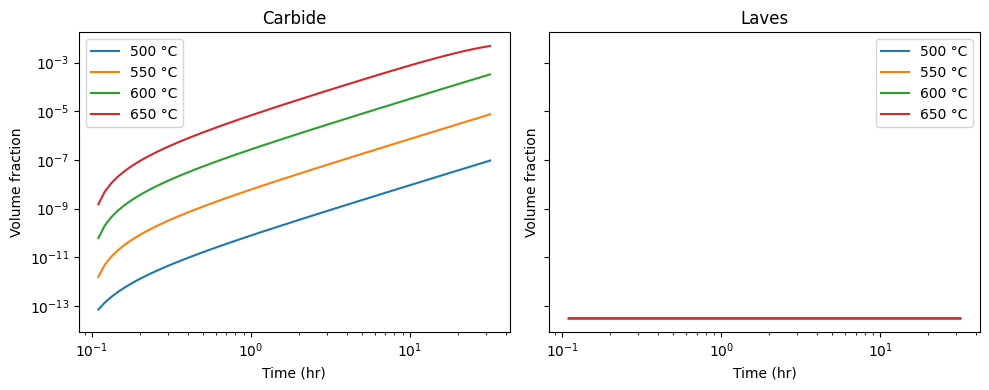

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
labels = [f"{T.item() - 273.15:.0f} °C" for T in T_K]
for j, lbl in enumerate(labels):
    axes[0].loglog(t_done, trace["vf_C"][:, j], label=lbl)
    axes[1].loglog(t_done, trace["vf_L"][:, j], label=lbl)
axes[0].set_title("Carbide")
axes[1].set_title("Laves")
for ax in axes:
    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("Volume fraction")
    ax.legend()
fig.tight_layout()

## Matrix solute concentrations vs time

C depletes rapidly as the carbide forms (C is the limiting reagent at this
composition), Cr drops only slightly (it's in excess), and Mo barely changes
because Laves nucleation is still in its lag phase at $t \le 10^3$ hr.

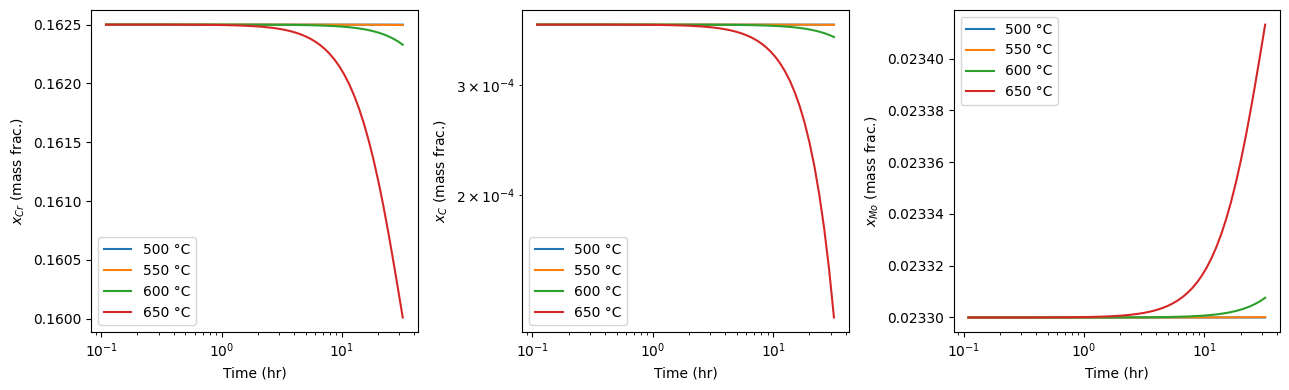

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for j, lbl in enumerate(labels):
    axes[0].semilogx(t_done, trace["x_Cr"][:, j], label=lbl)
    axes[1].loglog(t_done, trace["x_C"][:, j], label=lbl)
    axes[2].semilogx(t_done, trace["x_Mo"][:, j], label=lbl)
axes[0].set_ylabel("$x_{Cr}$ (mass frac.)")
axes[1].set_ylabel("$x_{C}$ (mass frac.)")
axes[2].set_ylabel("$x_{Mo}$ (mass frac.)")
for ax in axes:
    ax.set_xlabel("Time (hr)")
    ax.legend()
fig.tight_layout()

## Mean radius and number density per phase

Mean radius is the first moment of the size distribution:
$\bar R = \sum_i R_i n_i / \sum_i n_i$.

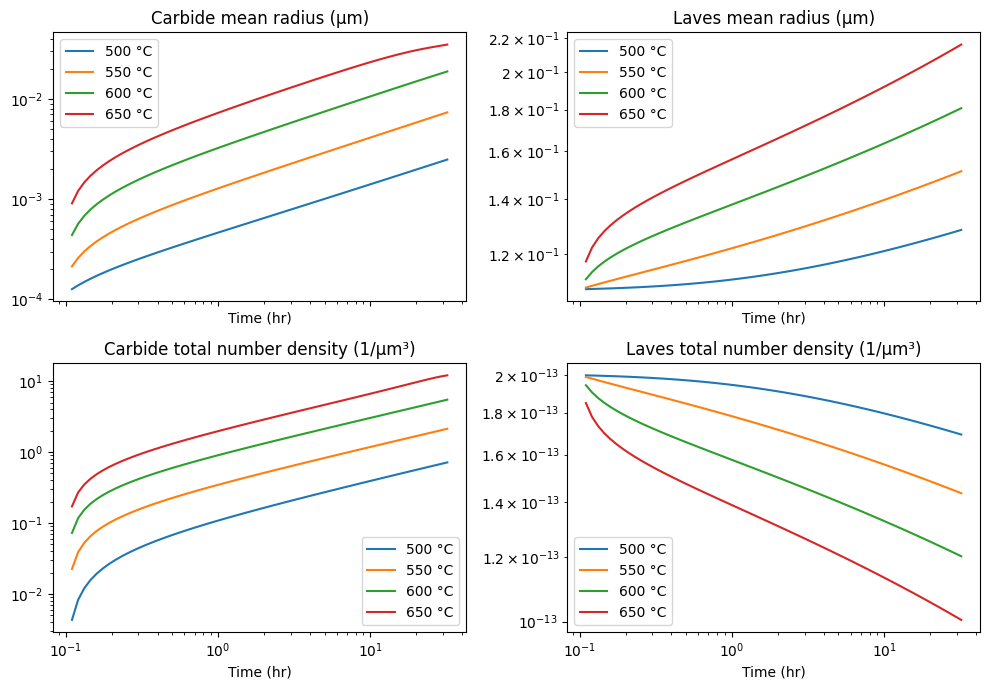

In [6]:
R = centers.cpu().numpy()
def moments(n):
    total = n.sum(axis=-1, keepdims=True)
    mean_R = (n * R).sum(axis=-1) / np.where(total[..., 0] > 0, total[..., 0], 1.0)
    return mean_R, total[..., 0]

mean_R_C, N_C = moments(trace["number_density_C"])
mean_R_L, N_L = moments(trace["number_density_L"])

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
for j, lbl in enumerate(labels):
    axes[0, 0].loglog(t_done, mean_R_C[:, j], label=lbl)
    axes[0, 1].loglog(t_done, mean_R_L[:, j], label=lbl)
    axes[1, 0].loglog(t_done, N_C[:, j], label=lbl)
    axes[1, 1].loglog(t_done, N_L[:, j], label=lbl)
axes[0, 0].set_title("Carbide mean radius (μm)")
axes[0, 1].set_title("Laves mean radius (μm)")
axes[1, 0].set_title("Carbide total number density (1/μm³)")
axes[1, 1].set_title("Laves total number density (1/μm³)")
for ax in axes.flat:
    ax.set_xlabel("Time (hr)")
    ax.legend()
fig.tight_layout()

## Final size distributions

Snapshot of $n(R)$ at the final time step. The carbide distribution at higher
temperatures has clearly spread to larger radii by coarsening, while the Laves
distribution is still effectively at its tiny initial condition.

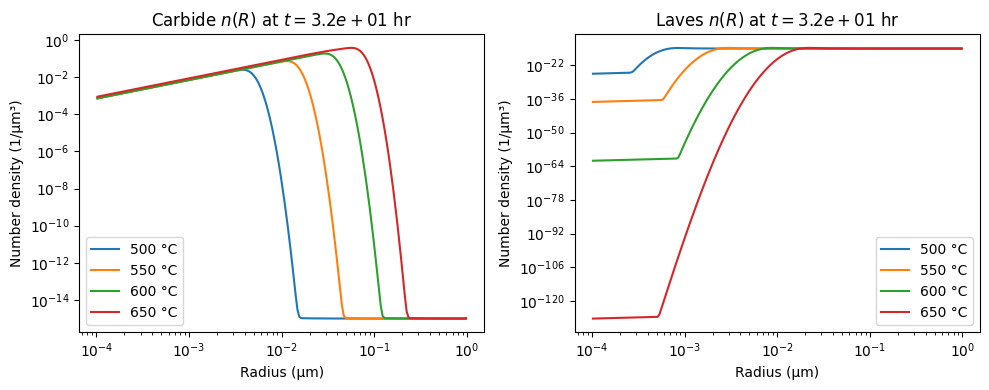

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for j, lbl in enumerate(labels):
    axes[0].loglog(R, trace["number_density_C"][-1, j], label=lbl)
    axes[1].loglog(R, trace["number_density_L"][-1, j], label=lbl)
axes[0].set_title(f"Carbide $n(R)$ at $t = {t_done[-1]:.1e}$ hr")
axes[1].set_title(f"Laves $n(R)$ at $t = {t_done[-1]:.1e}$ hr")
for ax in axes:
    ax.set_xlabel("Radius (μm)")
    ax.set_ylabel("Number density (1/μm³)")
    ax.legend()
fig.tight_layout()